<a href="https://colab.research.google.com/github/aerau05/ml_assignments/blob/main/linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1
1. A model is considered linear when the outcome variable is expressed as a linear combination of the model's paramters (coefficients). "Linear referts to linearity in the coefficients, not necessarily the input variables. This means each coefficient multiplies a feature and the terms are added together without being multiplied or exponentiated with other coefficients.
2. The coefficient for a dummy variable represents the expected change in the outcome variable when that category is present compared to the reference category. One category is typically omitted so that its effect is absorbed into the intercept. The intercept therefore represents the expected value of the outcome for the reference group, and each dummy variable coefficient shows how much the outcome differs from that baseline group.
3. Linear regression is generally not appropriate for classification because it predicts continuous values rather than probabilities or discrete classes. The predictions can fall outside the valid probability range of 0 to 1, which makes interpretation difficult. Classification models such as logistic regression are preferred because they transform predictions into probabilities bounded between 0 and 1.
4. Overfitting occurs when a model captures noise in the training data rather than the true underlying relationship. Common signs include very high performance on the training data but much worse performance on test or validation data. The model may also contain too many predictors relative to the data size or produce very unstable coefficients when the data changes slightly.
5. Multicollinearity occurs when two or more predictor variables are highly correlated, making it difficult to estimate their individual effects on the outcome variable. In two-stage least squares (2SLS), the correlated predictor is first regressed on other variables or instruments that are not correlated with the error term. The predicted values from this first regression are then used in the second regression to estimate the relationship with the outcome variable. This process isolates the independent variation in the predictor and reduces the bias caused by multicollinearity.
6. Nonlinear relationships can be incorporated by transforming the input variables or adding additional terms to the model. Common approaches include polynomial terms (such as x^2 or x^3), logarithmic transformations, interaction terms between variables, or spline functions. These techniques allow the model to capture curved or more complex relationships while still being estimated using linear regression.
7. The slope coefficient represents the expected change in the outcome variable for a one-unit increase in the predictor variable, holding all other variables constant. A positive slope indicates that the outcome increases as the predictor increases, while a negative slope indicates that the outcome decreases as the predictor increases.
8. A train/test split divides the dataset into two parts: one used to train the model and the other used to evaluate its performance. This approach is simple but the evaluation depends heavily on how the data is split. In k-fold cross validation, the dataset is divided into k subsets, and the model is trained k times, each time using a different subset as the validation set and the remaining data as training data. The performance results are then averaged, providing a more reliable estimate of model performance.
9. The value of k is chosen to balance computational cost and reliable performance estimation. A common choice is k=5 or k=10, which generally provides a good balance between bias and variance in the performance estimate. Larger values of k use more data for training in each iteration but require more computation.

DataFrame Columns: Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')
                    Price  Review_Scores_Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750
Most expensive borough on average:
Manhattan


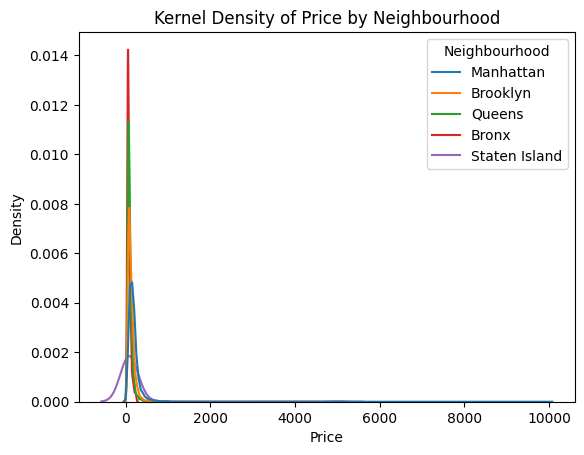

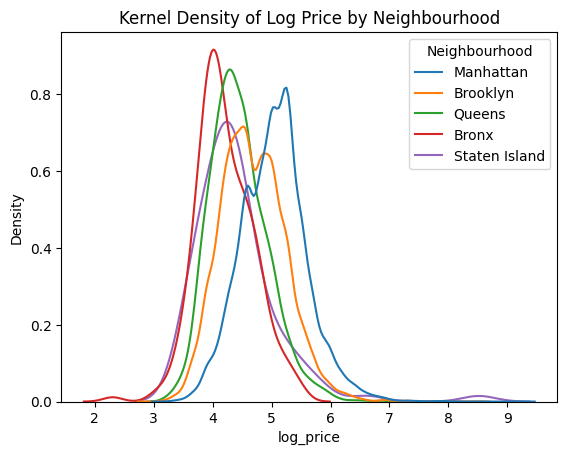

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        00:04:09   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

In [ ]:
# Question 2
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

# Load the data
df = pd.read_csv('/content/Q1_clean.csv')
print("DataFrame Columns:", df.columns)
df = df.rename(columns={'Review Scores Rating':'Review_Scores_Rating', 'Neighbourhood ':'Neighbourhood'})

# 1. Average prices and scores by Neighbourhood
group_means = df.groupby('Neighbourhood')[['Price','Review_Scores_Rating']].mean()
print(group_means)

# Identify most expensive borough
print("Most expensive borough on average:")
print(group_means['Price'].idxmax())

# 2. Kernel density plots of price and log(price)
sns.kdeplot(data=df, x='Price', hue='Neighbourhood', common_norm=False)
plt.title("Kernel Density of Price by Neighbourhood")
plt.show()

df['log_price'] = np.log(df['Price'])

sns.kdeplot(data=df, x='log_price', hue='Neighbourhood', common_norm=False)
plt.title("Kernel Density of Log Price by Neighbourhood")
plt.show()

# 3. Regress price on Neighbourhood (dummy variables)
X = pd.get_dummies(df['Neighbourhood'], drop_first=True).astype(int)  # drop_first avoids dummy variable trap
X = sm.add_constant(X)

y = df['Price']

model1 = sm.OLS(y, X).fit()
print(model1.summary())

# 4. Regress price on Review Scores Rating
X2 = sm.add_constant(df['Review_Scores_Rating'])

model2 = sm.OLS(y, X2).fit()
print(model2.summary())

# 5. Regress price on Neighbourhood + Review Scores Rating
X3 = pd.get_dummies(df[['Neighbourhood','Review_Scores_Rating']], drop_first=True).astype(int)
X3 = sm.add_constant(X3)

model3 = sm.OLS(y, X3).fit()
print(model3.summary())

# 6. Different slope for Review Scores Rating by neighborhood
# interaction terms
df_dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True).astype(int)

X4 = pd.concat([df['Review_Scores_Rating'], df_dummies], axis=1)

# interaction terms
for col in df_dummies.columns:
    X4[f'{col}_rating'] = df['Review_Scores_Rating'] * df_dummies[col]

X4 = sm.add_constant(X4)

model4 = sm.OLS(y, X4).fit()
print(model4.summary())

# 7. Cross-validation for models 4, 5, and 6
kf = KFold(n_splits=5, shuffle=True, random_state=1)
lr = LinearRegression()

# Prepare matrices for sklearn
X_model2 = df[['Review_Scores_Rating']]
X_model3 = pd.get_dummies(df[['Neighbourhood','Review_Scores_Rating']], drop_first=True).astype(int)

# Interaction model
X_model4 = X4.drop(columns='const')

scores2 = cross_val_score(lr, X_model2, y, cv=kf, scoring='r2')
scores3 = cross_val_score(lr, X_model3, y, cv=kf, scoring='r2')
scores4 = cross_val_score(lr, X_model4, y, cv=kf, scoring='r2')

print("Model 4 CV R2:", scores2.mean())
print("Model 5 CV R2:", scores3.mean())
print("Model 6 CV R2:", scores4.mean())

1. The average price per night and review scores were computed for each borough. Manhattan has the highest average price at about \$183.66 per night, making it the most expensive borough on average. It is followed by Staten Island ($146.17), Brooklyn (\$127.75), Queens (\$96.86), and the Bronx (\$75.28). The review scores are relatively similar across boroughs, all around 90–92 on average, suggesting ratings do not vary dramatically by location. Kernel density plots of price and log(price) show that the distribution of prices is highly right-skewed, with many listings at lower prices and a smaller number of very expensive listings. Taking the log of price produces a more symmetric distribution and makes it easier to compare price patterns across neighborhoods.

2. To regress price on neighbourhood, dummy variables were created and the Bronx was used as the reference category, meaning it is captured by the intercept. The intercept of 75.28 therefore represents the average price in the Bronx. The coefficients for the other boroughs represent the difference in average price relative to the Bronx. For example, the coefficient for Manhattan is 108.39, meaning listings in Manhattan cost about \$108 more per night on average than listings in the Bronx. Similarly, Brooklyn listings cost about \$52 more, Queens about \$22 more, and Staten Island about \$71 more than the Bronx. These coefficients correspond directly to the conditional group means from the table in part 1. In other words, the regression reproduces the group averages by expressing them as the intercept plus the relevant dummy coefficient.

3. When regressing price on Review Scores Rating with an intercept, the slope coefficient is 1.0208. This means that for every one-point increase in review score rating, the predicted price per night increases by about \$1.02 on average. In other words, properties with slightly higher ratings tend to charge slightly higher prices, although the effect is relatively small.

4. When both neighbourhood and review scores are included in the regression, the coefficient on Review Scores Rating becomes 1.0811, which is slightly larger than in the previous model. This means that after controlling for neighborhood differences, a one-point increase in rating is associated with about a \$1.08 increase in nightly price. The neighborhood coefficients remain similar to the earlier regression because borough differences explain much of the variation in prices. For example, Manhattan listings are still predicted to be about $108 more expensive than Bronx listings, while Brooklyn listings are about \$52 more expensive, holding review scores constant.

5. In this model, interaction terms allow each borough to have its own slope for Review Scores Rating. The results suggest that the slopes are generally similar for most boroughs, with small positive values for Brooklyn and Manhattan and near zero for Queens. However, the slope for Staten Island is very different and strongly negative, indicating that the relationship between ratings and price in Staten Island differs substantially from the other boroughs. Overall, the relationship between ratings and price appears relatively weak and inconsistent across neighborhoods.

6. Cross-validation was used to evaluate the predictive performance of the three models. The model using only review scores performed very poorly, with a cross-validated R^2 of about 0.0037, indicating that ratings alone explain almost none of the variation in price. The model including neighborhood and review scores performed best, with a cross-validated R^2 of about 0.056, suggesting that location provides useful predictive information. The model allowing different slopes by neighborhood had a slightly lower performance (
𝑅
2
≈
0.046
R
2
≈0.046), indicating that the additional complexity does not substantially improve predictive accuracy. Overall, neighborhood appears to be the most important factor in predicting Airbnb prices in this dataset.

In [21]:
! git clone https://github.com/aerau05/scratchpad
%cd scratchpad
!ls
%run get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 27 (delta 4), reused 4 (delta 4), pack-reused 18 (from 1)
Receiving objects: 100% (27/27), 44.09 KiB | 2.45 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/scratchpad/scratchpad/scratchpad/scratchpad/scratchpad/scratchpad/scratchpad/scratchpad/scratchpad/scratchpad
'ds3001(1_20).ipynb'   get_data.py   nb_2026_01_05.ipynb   README.md
Download complete
Extracting data files...
Data extracted


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


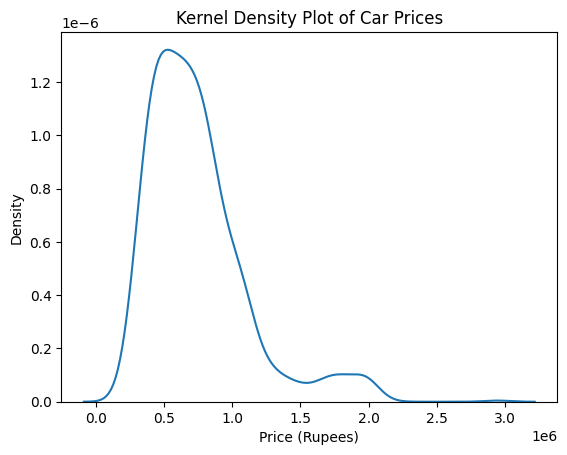

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


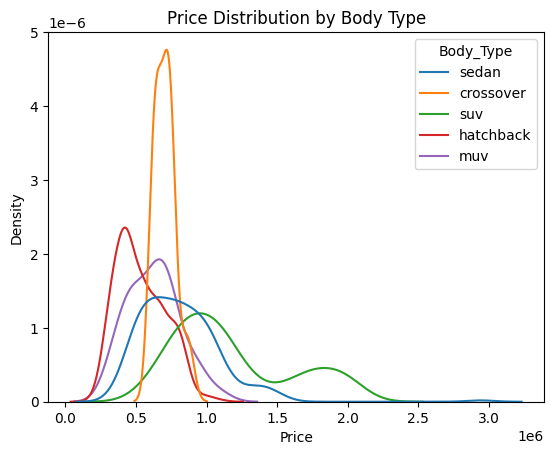

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Mon, 16 Mar 2026   Prob (F-statistic):             0.0245
Time:                        00:47:55   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


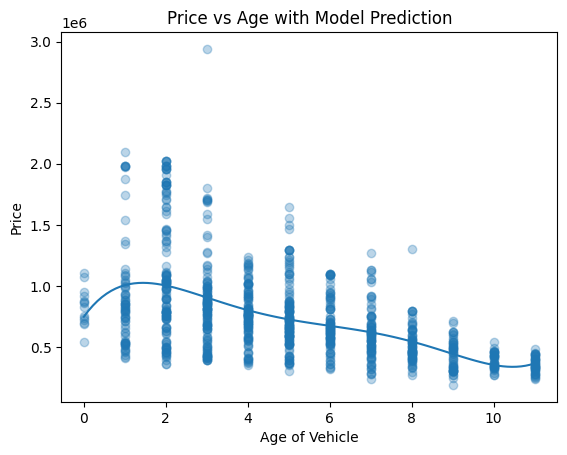

In [23]:
# Question 3
df = pd.read_csv('/content/scratchpad/data/cars_hw.csv',encoding='latin1')
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# 1. Summarize Price and create kernel density plot

print(df['Price'].describe())

sns.kdeplot(df['Price'])
plt.title("Kernel Density Plot of Car Prices")
plt.xlabel("Price (Rupees)")
plt.show()

# 2. Summarize prices by Body_Type

price_by_body = df.groupby('Body_Type')['Price'].describe()
print(price_by_body)

# grouped KDE plot
sns.kdeplot(data=df, x='Price', hue='Body_Type', common_norm=False)
plt.title("Price Distribution by Body Type")
plt.show()

# 3. Regress Price on Seating_Capacity (numeric)

X = sm.add_constant(df['Seating_Capacity'])
y = df['Price']

model1 = sm.OLS(y, X).fit()
print(model1.summary())

# 4. Treat Seating_Capacity as categorical

X_cat = pd.get_dummies(df['Seating_Capacity'], drop_first=True).astype(int)
X_cat = sm.add_constant(X_cat, prepend=False) # Changed prepend to False as const should be first or handled by sm.OLS

model2 = sm.OLS(y, X_cat).fit()
print(model2.summary())

# 5. Create Age variable

current_year = df['Make_Year'].max()
df['Age'] = current_year - df['Make_Year']

# 6. Cross validation to determine polynomial degree

X_age = df[['Age']]
y = df['Price']

kf = KFold(n_splits=10, shuffle=True, random_state=1)

degrees = range(1, 6)
scores = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    cv_score = cross_val_score(model, X_age, y, cv=kf, scoring='r2')
    scores.append(cv_score.mean())

print("Cross-validation scores by polynomial degree:")
for d, s in zip(degrees, scores):
    print(d, s)

best_degree = degrees[np.argmax(scores)]
print("Best polynomial degree:", best_degree)

# 7. Fit final polynomial model

final_model = make_pipeline(PolynomialFeatures(best_degree), LinearRegression())
final_model.fit(X_age, y)

# Predictions for plotting
age_range = np.linspace(df['Age'].min(), df['Age'].max(), 100).reshape(-1,1)
pred_price = final_model.predict(age_range)


# 8. Plot Price vs Age and predicted model

plt.scatter(df['Age'], df['Price'], alpha=0.3)
plt.plot(age_range, pred_price)
plt.xlabel("Age of Vehicle")
plt.ylabel("Price")
plt.title("Price vs Age with Model Prediction")
plt.show()

1. SUVs are the most expensive car type on average, with a mean price of about 1,176,495 rupees. Sedans are the next most expensive, followed by crossovers and MUVs, while hatchbacks are the least expensive. SUVs also have the largest variance in price, as shown by their highest standard deviation (about 417,479 rupees), indicating that SUV prices vary widely across different models.

2. The slope coefficient is approximately 59,270. This means that for every additional seat in a vehicle, the predicted price increases by about 59,000 rupees on average. In other words, vehicles with larger seating capacity tend to be more expensive. When seating capacity is treated as a categorical variable, the estimated coefficients for each seating category do not increase consistently with the number of seats. This suggests that the relationship between seating capacity and price is not perfectly linear, and some seating configurations are associated with larger price differences than others.

4. The model captures the overall pattern that car prices decrease as vehicles become older, reflecting depreciation over time. However, there is still substantial variation in prices for vehicles of the same age, indicating that other factors such as body type, brand, and features also affect price. Therefore, the model fits the general trend but does not fully explain all variation in car prices.

Survival rates by group:
transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
Average Treatment Effect: 0.23017902813299232
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Mon, 16 Mar 2026   Prob (F-statistic):             0.0133
Time:                        01:22:20   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t| 

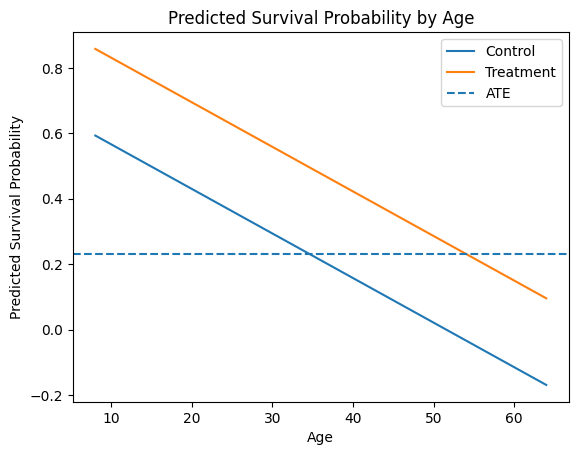

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           0.000310
Time:                        01:22:20   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3549      0.280     

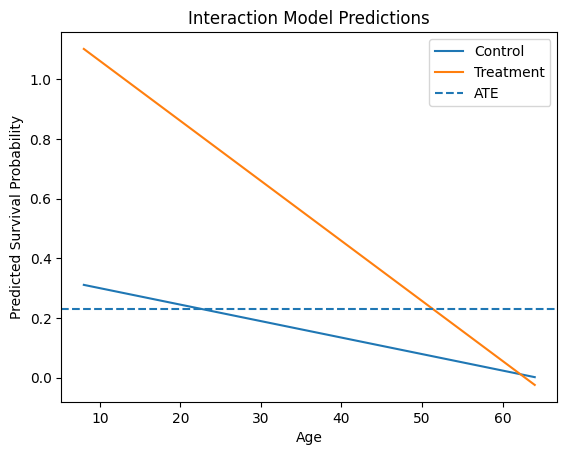

Model 1 CV R2: -0.0011081935172854607
Model 2 CV R2: 0.07011425737924556
Model 3 CV R2: 0.069150082831016


In [27]:
# Question 4
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
df = pd.read_csv("/heart_hw.csv")

# 1. Compute survival proportions

survival_rates = df.groupby("transplant")["y"].mean()
print("Survival rates by group:")
print(survival_rates)

control_survival = survival_rates["control"]
treatment_survival = survival_rates["treatment"]

ATE = treatment_survival - control_survival
print("Average Treatment Effect:", ATE)

# 2. Regression: y on transplant

df["treatment_dummy"] = (df["transplant"] == "treatment").astype(int)

X1 = sm.add_constant(df["treatment_dummy"])
y = df["y"]

model1 = sm.OLS(y, X1).fit()
print(model1.summary())

# 3. Regression: y on transplant and age

X2 = sm.add_constant(df[["treatment_dummy","age"]])
model2 = sm.OLS(y, X2).fit()
print(model2.summary())

# Predicted survival probabilities by age
age_range = np.linspace(df["age"].min(), df["age"].max(), 100)

control_pred = model2.params["const"] + model2.params["age"]*age_range
treat_pred = (model2.params["const"]
              + model2.params["treatment_dummy"]
              + model2.params["age"]*age_range)

plt.plot(age_range, control_pred, label="Control")
plt.plot(age_range, treat_pred, label="Treatment")

plt.axhline(ATE, linestyle="dashed", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.legend()
plt.title("Predicted Survival Probability by Age")
plt.show()

# 4. Interaction model

df["interaction"] = df["treatment_dummy"] * df["age"]

X3 = sm.add_constant(df[["treatment_dummy","age","interaction"]])
model3 = sm.OLS(y, X3).fit()
print(model3.summary())

# Predictions
control_pred_int = model3.params["const"] + model3.params["age"]*age_range
treat_pred_int = (model3.params["const"]
                  + model3.params["treatment_dummy"]
                  + model3.params["age"]*age_range
                  + model3.params["interaction"]*age_range)

plt.plot(age_range, control_pred_int, label="Control")
plt.plot(age_range, treat_pred_int, label="Treatment")

plt.axhline(ATE, linestyle="dashed", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.legend()
plt.title("Interaction Model Predictions")
plt.show()

# 5. Cross validation

kf = KFold(n_splits=10, shuffle=True, random_state=1)
lr = LinearRegression()

X_cv1 = df[["treatment_dummy"]]
X_cv2 = df[["treatment_dummy","age"]]
X_cv3 = df[["treatment_dummy","age","interaction"]]

scores1 = cross_val_score(lr, X_cv1, y, cv=kf, scoring="r2")
scores2 = cross_val_score(lr, X_cv2, y, cv=kf, scoring="r2")
scores3 = cross_val_score(lr, X_cv3, y, cv=kf, scoring="r2")

print("Model 1 CV R2:", scores1.mean())
print("Model 2 CV R2:", scores2.mean())
print("Model 3 CV R2:", scores3.mean())

1. The average treatment effect (ATE) represents the difference in survival rates between patients who received a heart transplant and those who did not. It is calculated as the proportion of survivors in the treatment group minus the proportion of survivors in the control group. A positive ATE indicates that transplant recipients have a higher probability of surviving three years compared to patients who did not receive a transplant.

2. In the regression of survival on transplant status, the intercept represents the average survival probability for the control group. The coefficient on the transplant variable represents the difference in survival probability between the treatment and control groups. Therefore, the intercept corresponds to the control group survival rate, and the transplant coefficient corresponds exactly to the average treatment effect calculated in part 1.

3. When age is included in the regression, the coefficient on transplant reflects the effect of receiving a transplant while holding age constant. This may change the estimated treatment effect if transplant recipients differ systematically in age from those in the control group. In this model, the intercept represents the predicted survival probability for a control-group patient when age equals zero, and the slope on age represents the change in predicted survival probability associated with a one-year increase in age.

4. The constant ATE represents an average effect across all ages, while the regression model allows predicted survival to vary with age. If the predicted difference between treatment and control groups is larger than the ATE at certain ages, the ATE underestimates the effect of a transplant for those patients. If the predicted difference is smaller than the ATE at other ages, the ATE overestimates the effect. This occurs because the ATE averages the treatment effect across individuals with different characteristics.

5. Allowing age and transplant to interact means that the effect of receiving a transplant can vary depending on the patient’s age. Instead of assuming the same treatment effect for all patients, the model allows the difference in survival probability between treatment and control groups to change as age increases. This may reveal patterns such as transplants being more beneficial for younger patients or less effective for older patients.

6. There are several concerns about using this model to prioritize transplant access. First, the model may omit important variables such as patient health status, underlying conditions, or lifestyle factors that affect survival. Second, the data may contain selection bias if patients who receive transplants differ systematically from those who do not. Third, relying solely on a statistical model for life-and-death decisions raises ethical concerns, since models may reinforce existing inequalities or make incorrect predictions for certain groups. Therefore, such models should be used cautiously and alongside clinical judgment rather than as the sole decision-making tool.